#  Pipeline Astrofísico Híbrido: Detección y Clasificación de Objetos de Espacio Profundo
**Proyecto:** Modelo V1 - Detección de Galaxias con IA y Astrometría Física

Este cuaderno automatiza el proceso completo de reducción de datos astronómicos. 

### Arquitectura del Pipeline:
1. **Preparación de Datos:** Organización automática de archivos `.fits` leyendo sus metadatos internos.
2. **Reducción Óptica (Física):** Limpieza de ruido instrumental (Bias, Dark, Flat).
3. **Limpieza con IA 1 (`deepCR`):** Eliminación de rayos cósmicos por redes neuronales.
4. **Resolución Astrométrica (`astroquery`):** Conexión con *Astrometry.net* para mapear la imagen contra las constelaciones reales y obtener el WCS.
5. **Detección (`YOLO`):** Búsqueda de objetos celestes.
6. **Morfología (IA 2 - Placeholder):** Segunda red neuronal para clasificar la forma (Espiral, Elíptica, Estrella).
7. **Validación:** Cruce trigonométrico con el satélite Gaia para confirmar si la IA acertó.

In [ ]:
# ==============================================================================
# 1. CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import sys
import subprocess

def instalar_dependencias():
    print("⏳ Verificando entorno e instalando dependencias...")
    paquetes = ["numpy<2.0", "pandas", "matplotlib", "astropy", "astroquery", "opencv-python", "ultralytics"]
    for paquete in paquetes:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])
        
    try:
        import deepCR
    except ImportError:
        print("Instalando PyTorch y deepCR (Versión CPU para máxima compatibilidad)...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", 
                               "torch", "torchvision", "torchaudio", "deepCR", 
                               "--index-url", "https://download.pytorch.org/whl/cpu"])
    print("✅ ¡Entorno configurado correctamente!")

instalar_dependencias()

⏳ Verificando entorno e instalando dependencias...
✅ ¡Entorno configurado correctamente!


In [1]:
# ==============================================================================
# 2. IMPORTACIÓN DE MÓDULOS
# ==============================================================================
import os
import glob
import shutil
import cv2
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
from PIL import Image
import shutil

import time
import threading
import sys

from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import ZScaleInterval, LogStretch, ImageNormalize
from astroquery.astrometry_net import AstrometryNet
import subprocess
from astroquery.astrometry_net import AstrometryNet
from astroquery.simbad import Simbad
import subprocess
from astropy.wcs import WCS


from deepCR import deepCR
from ultralytics import YOLO

import torch
import torch.nn as nn
from torchvision import transforms

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ==============================================================================
# 3. ORGANIZADOR DE DATOS CRUDOS
# ==============================================================================
class OrganizadorFITS:
    def __init__(self, ruta_base):
        self.ruta_base = ruta_base
        self.carpetas = ["Bias", "Dark", "Flat", "Science"]
        for c in self.carpetas:
            os.makedirs(os.path.join(self.ruta_base, c), exist_ok=True)

    def organizar(self):
        print(f"🧹 Analizando ADN de archivos FITS en: {self.ruta_base}")
        archivos = [f for f in os.listdir(self.ruta_base) if f.endswith(('.fits', '.fit'))]
        
        for archivo in archivos:
            ruta_full = os.path.join(self.ruta_base, archivo)
            try:
                with fits.open(ruta_full) as hdul:
                    # El LCO guarda el tipo en OBSTYPE o IMAGETYP
                    header = hdul[0].header
                    tipo = header.get('OBSTYPE', header.get('IMAGETYP', 'UNKNOWN')).upper()
                
                destino = "Science" # Por defecto
                if "BIAS" in tipo: destino = "Bias"
                elif "DARK" in tipo: destino = "Dark"
                elif "FLAT" in tipo: destino = "Flat"
                elif "EXPOSE" in tipo or "SCIENCE" in tipo: destino = "Science"
                
                shutil.move(ruta_full, os.path.join(self.ruta_base, destino, archivo))
            except Exception as e:
                print(f"   ⚠️ No se pudo leer {archivo}: {e}")
        
        print("✅ Organización completada por metadatos.")

In [3]:
# ==============================================================================
# 4. MOTOR DE REDUCCIÓN (Creador de Masters + Física + deepCR)
# ==============================================================================
class MotorReduccion:
    def __init__(self, dispositivo="GPU"):
        import torch
        dispositivo_ia = "cuda" if torch.cuda.is_available() and dispositivo=="GPU" else "cpu"
        self.ia_limpieza = deepCR(mask="decam", device=dispositivo_ia)

    def leer_fits(self, ruta):
        with fits.open(ruta) as hdul:
            ext = 1 if len(hdul) > 1 and hdul[0].data is None else 0
            return hdul[ext].data.astype(np.float32), hdul[ext].header

    def crear_master(self, carpeta_origen, ruta_salida, tipo="Bias"):
        """Apila múltiples imágenes usando la mediana estadística simple."""
        archivos = glob.glob(os.path.join(carpeta_origen, "*.fit*"))
        if not archivos:
            return None
            
        print(f"   🥞 Apilando {len(archivos)} imágenes para crear Master {tipo}...")
        datos_apilados = []
        header_base = None
        
        for archivo in archivos:
            data, header = self.leer_fits(archivo)
            if header_base is None: header_base = header
            datos_apilados.append(data)
            
        master_data = np.nanmedian(np.stack(datos_apilados, axis=0), axis=0)
        fits.PrimaryHDU(data=master_data.astype(np.float32), header=header_base).writeto(ruta_salida, overwrite=True)
        return ruta_salida

    def calibrar_imagen(self, ruta_science, r_bias, r_dark, r_flat, ruta_salida_fits):
        print(f"\n🧪 Calibrando imagen científica con física óptica: {os.path.basename(ruta_science)}")
        
        ciencia, header = self.leer_fits(ruta_science)
        
        # ==========================================================
        # 🛡️ FUNCIÓN AUXILIAR: VERIFICADOR GEOMÉTRICO
        # ==========================================================
        def cargar_calibracion(ruta, nombre_tipo):
            if ruta and os.path.exists(ruta):
                data = self.leer_fits(ruta)[0]
                # Si los sensores no miden lo mismo, rechazamos la calibración
                if data.shape == ciencia.shape:
                    return data
                else:
                    print(f"   ⚠️ ADVERTENCIA: {nombre_tipo} es de {data.shape} y la imagen de {ciencia.shape}.")
                    print(f"      Ignorando {nombre_tipo} por incompatibilidad de telescopio/cámara.")
            return None

        # 1. Cargar Masters con seguro geométrico
        bias_cargado = cargar_calibracion(r_bias, "Master Bias")
        dark_cargado = cargar_calibracion(r_dark, "Master Dark")
        flat_cargado = cargar_calibracion(r_flat, "Master Flat")

        # Si no hay archivos compatibles, generamos matrices neutras
        bias = bias_cargado if bias_cargado is not None else np.zeros_like(ciencia)
        dark_bruto = dark_cargado if dark_cargado is not None else np.zeros_like(ciencia)
        flat_bruto = flat_cargado if flat_cargado is not None else np.ones_like(ciencia)

        # 2. Corrección Matemática Óptica
        dark_termico = np.maximum(dark_bruto - bias, 0)
        
        flat_limpio = np.maximum(flat_bruto - bias, 0.0001)
        mediana_flat = np.nanmedian(flat_limpio)
        flat_norm = flat_limpio / mediana_flat if mediana_flat > 0 else flat_limpio

        # 3. Aplicar Ecuación
        calibrada = (ciencia - bias - dark_termico) / flat_norm

        print("   ✨ Borrando radiación transitoria (Rayos Cósmicos) con deepCR...")
        _, perfecta = self.ia_limpieza.clean(calibrada, inpaint=True)

        # Guardar FITS
        from astropy.io import fits
        fits.PrimaryHDU(data=perfecta, header=header).writeto(ruta_salida_fits, overwrite=True)
        
        # Guardar PNG (Ajuste visual)
        ruta_salida_png = ruta_salida_fits.replace(".fits", ".png")
        self._exportar_png(perfecta, ruta_salida_png)
        
        return ruta_salida_png

    def _exportar_png(self, matriz_datos, ruta_salida):
        # Mejora en la visualización (ZScale es el estándar para resaltar galaxias tenues)
        datos_seguros = np.nan_to_num(matriz_datos, nan=np.nanmedian(matriz_datos))
        vmin, vmax = ZScaleInterval().get_limits(datos_seguros)
        img_norm = (np.clip(datos_seguros, vmin, vmax) - vmin) / (vmax - vmin)
        plt.imsave(ruta_salida, np.flipud((img_norm * 255).astype(np.uint8)), cmap='gray')

In [4]:
# ==============================================================================
# 4.5 ESTRUCTURA DE LA RED NEURONAL (AstroNet DECals)
# ==============================================================================
class AstroNetDECals(nn.Module):
    def __init__(self):
        super(AstroNetDECals, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10) # Las 10 clases de galaxias
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

### 🌐 ¿Qué ocurre en la resolución del cielo? (Plate Solving)
Cuando enviamos nuestra imagen PNG a través de `astroquery.astrometry_net`, no estamos haciendo una búsqueda por imagen en Google. Estamos utilizando trigonometría esférica masiva:
1. **Extracción:** Los servidores de la API detectan los puntos más brillantes de nuestra foto (las estrellas).
2. **Fingerprinting (Geometría):** Miden los triángulos y ángulos que forman esas estrellas entre sí. Como las estrellas están tan lejos, estas figuras geométricas son idénticas sin importar con qué telescopio se miren.
3. **Cruce de Datos:** Comparan esta "huella digital geométrica" con su base de datos de todo el universo observable.
4. **Traducción Matemática (WCS):** Al encontrar una coincidencia, la API nos devuelve una matriz matemática llamada **WCS (World Coordinate System)**. Esta matriz nos permite traducir un simple `Píxel X=400, Y=250` a coordenadas espaciales reales `Ascensión Recta (RA)` y `Declinación (Dec)`.

In [5]:
# ==============================================================================
# 5. MOTOR ASTROMÉTRICO Y MORFOLÓGICO (YOLO + IA2 +Gaia)
# ==============================================================================
class ExploradorCeleste:
    def __init__(self, ruta_yolo, api_key_astrometry, ruta_modelo_morfologico):
        self.detector_yolo = YOLO(ruta_yolo)
        self.api = AstrometryNet()
        self.api.api_key = api_key_astrometry
        
        # --- INICIALIZAR LA IA MORFOLÓGICA (PyTorch) ---
        print("🧠 Despertando a la IA Morfológica...")
        self.dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.modelo_morfologico = AstroNetDECals().to(self.dispositivo)
        
        # Cargar los pesos aprendidos y ponerla en modo "evaluación"
        self.modelo_morfologico.load_state_dict(torch.load(ruta_modelo_morfologico, map_location=self.dispositivo))
        self.modelo_morfologico.eval()
        
        # Las mismas transformaciones que usamos en el entrenamiento
        self.transformaciones = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
        # Diccionario de traducción de clases
        self.nombres_clases = [
            "Disco de frente (Sin Espiral)", "Elíptica Redonda", "Elíptica Intermedia", 
            "Elíptica Forma de cigarro", "Disco de canto (Bulbo redondo)", 
            "Disco de canto (Bulbo cuadrado)", "Disco de canto (Sin bulbo)", 
            "Espiral Apretada", "Espiral Media", "Espiral Suelta"
        ]
        print("✅ Sistemas de IA 100% operativos.")

    def _extraer_pistas_fits(self, ruta):
        """Detective de metadatos universal (Soporta Palomar, LCO, SDSS)."""
        import astropy.io.fits as fits
        from astropy.coordinates import SkyCoord
        import astropy.units as u
        
        header = fits.getheader(ruta)
        ancho = header.get('NAXIS1', 2048)
        
        # 1. Búsqueda exhaustiva de la escala del píxel
        if 'PIXSCALE' in header:      # Estándar LCO
            escala = float(header['PIXSCALE']) / 3600.0
        elif 'SECPIX1' in header:     # Estándar Palomar LFC
            escala = float(header['SECPIX1']) / 3600.0
        elif 'CDELT1' in header:      # Estándar WCS
            escala = abs(float(header['CDELT1']))
        elif 'CD1_1' in header:       # Matriz WCS alternativa
            escala = abs(float(header['CD1_1']))
        else:
            escala = 0.57 / 3600.0    # Rescate genérico LCO 0.4m
            
        fov = escala * ancho
        
        # 2. Búsqueda de coordenadas
        ra_str = header.get('RA', header.get('OBJCTRA', "148.888"))
        dec_str = header.get('DEC', header.get('OBJCTDEC', "69.065"))
        c = SkyCoord(ra_str, dec_str, unit=(u.hourangle, u.deg) if ":" in str(ra_str) else (u.deg, u.deg))
        
        return {'ra': c.ra.deg, 'dec': c.dec.deg, 'fov': fov}

    def clasificador_ia_morfologico(self, recorte_img_cv2):
        """Devuelve la clase ganadora, su confianza, y el detalle del Top 3 (Modo Transparente)."""
        from PIL import Image
        import torch
        
        img_rgb = cv2.cvtColor(recorte_img_cv2, cv2.COLOR_BGR2RGB)
        img_tensor = self.transformaciones(Image.fromarray(img_rgb)).unsqueeze(0).to(self.dispositivo)
        
        with torch.no_grad():
            output = self.modelo_morfologico(img_tensor)
            # Sacamos las probabilidades del batch actual
            probabilidades = torch.nn.functional.softmax(output, dim=1)[0] 
            
            # Usamos la magia de PyTorch para obtener directamente los 3 valores más altos
            cantidad_clases = min(3, len(self.nombres_clases))
            top_probs, top_indices = torch.topk(probabilidades, cantidad_clases)
            
        # 1. Extraemos el Top 1 (El ganador oficial para el cuadro verde)
        clase_top1 = self.nombres_clases[top_indices[0].item()]
        conf_top1 = top_probs[0].item() * 100
        
        # 2. Construimos el reporte de "Inteligencia Explicable"
        detalles = []
        for i in range(cantidad_clases):
            clase = self.nombres_clases[top_indices[i].item()]
            conf = top_probs[i].item() * 100
            detalles.append(f"{i+1}. {clase} ({conf:.1f}%)")
            
        detalle_top3 = " | ".join(detalles)
            
        return clase_top1, conf_top1, detalle_top3

    def resolver_cielo(self, ruta_calibrada, ruta_cruda):
        """Intenta resolver el cielo dejando que ASTAP lea los metadatos directamente."""
        print("   🚀 Iniciando búsqueda astrométrica (Modo Autónomo)...")
        ruta_astap = r"C:\Program Files\astap\astap.exe"
        
        caminos_a_probar = [ruta_calibrada, ruta_cruda]
        
        for i, ruta in enumerate(caminos_a_probar):
            tipo = "LIMPIA" if i == 0 else "CRUDA"
            print(f"   ⏳ Intentando resolver con imagen {tipo}...")
            
            ruta_wcs = ruta.replace(".fits", ".wcs")
            if os.path.exists(ruta_wcs): os.remove(ruta_wcs)

            # COMANDO MINIMALISTA: 
            # Solo le damos el archivo y un radio de 15°. ASTAP sacará el resto del FITS.
            comando = [
                ruta_astap, 
                "-f", ruta,
                "-r", "15" 
            ]

            try:
                import subprocess
                resultado = subprocess.run(comando, capture_output=True, text=True, timeout=30)
                
                if os.path.exists(ruta_wcs):
                    print(f"   ✅ ¡Cielo resuelto usando imagen {tipo}!")
                    import astropy.io.fits as fits
                    return fits.Header.fromtextfile(ruta_wcs)
                else:
                    # Si falla, leemos el archivo .ini que ASTAP genera en secreto
                    ruta_ini = ruta.replace(".fits", ".ini")
                    if os.path.exists(ruta_ini):
                        with open(ruta_ini, 'r') as f: lineas = f.readlines()
                        print(f"   ⚠️ ASTAP falló. Log interno: {lineas[-1].strip() if lineas else 'Vacío'}")
                    else:
                        print("   ⚠️ ASTAP falló y no dejó reporte.")
            except subprocess.TimeoutExpired:
                print(f"   ⚠️ ASTAP se quedó sin tiempo con la imagen {tipo}.")
            except Exception as e:
                print(f"   ⚠️ Error ejecutando ASTAP: {e}")

        # PLAN B (Mapa de Contingencia)
        print("   🛡️ Activando Plan B (Mapa de Contingencia)...")
        pistas = self._extraer_pistas_fits(ruta_calibrada)
        from astropy.wcs import WCS
        w = WCS(naxis=2)
        w.wcs.crpix = [1200, 1200] # LCO sq33 suele ser de 2400x2400
        escala = pistas['fov'] / 2400 if pistas['fov'] > 0 else 0.00015
        w.wcs.cdelt = [-escala, escala]
        w.wcs.crval = [pistas['ra'], pistas['dec']]
        w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
        return w.to_header()

    def consultar_nombre_simbad(self, ra, dec, es_plan_b=False):
        """Consulta usando un CSV local (Máscara de Galaxias) y SIMBAD como respaldo."""
        ra_float, dec_float = float(ra), float(dec)
        
        # ==========================================================
        # 🛡️ PLAN C: LECTURA DEL CATÁLOGO LOCAL CSV
        # ==========================================================
        try:
            import pandas as pd
            import os
            
            ruta_csv = "catalogo_local.csv"
            if os.path.exists(ruta_csv):
                catalogo = pd.read_csv(ruta_csv)
                
                for index, fila in catalogo.iterrows():
                    # Calculamos si las coordenadas caen dentro de la tolerancia (caja) del objeto
                    dist_ra = abs(ra_float - float(fila['RA']))
                    dist_dec = abs(dec_float - float(fila['Dec']))
                    tolerancia = float(fila['Tolerancia'])
                    
                    if dist_ra < tolerancia and dist_dec < tolerancia:
                        return str(fila['Nombre'])
        except Exception as e:
            print(f"      ⚠️ Advertencia: No se pudo leer catalogo_local.csv ({e})")

        # ==========================================================
        # 🌐 RED SIMBAD (Para objetos que no están en tu CSV)
        # ==========================================================
        radio = 180 if es_plan_b else 30 
        
        try:
            from astroquery.simbad import Simbad
            from astropy.coordinates import SkyCoord
            import astropy.units as u
            
            Simbad.TIMEOUT = 15 
            print(f"      🌐 Consultando base de datos SIMBAD (RA:{ra_float:.3f}, Dec:{dec_float:.3f})...")
            coord = SkyCoord(ra=ra_float*u.degree, dec=dec_float*u.degree, frame='icrs')
            resultado = Simbad.query_region(coord, radius=radio * u.arcsec)
            
            if resultado is not None and len(resultado) > 0:
                nombre_columna_principal = resultado.colnames[0]
                nombre = resultado[nombre_columna_principal][0]
                return str(nombre.decode('utf-8') if isinstance(nombre, bytes) else nombre)
            
            return "DSO no catalogado"
            
        except Exception as e:
            print(f"      ⚠️ SIMBAD no disponible: Usando coordenadas como ID.")
            return "Objeto detectado (Sin conexión)"

    def analizar_vecindario_estelar(self, ra_centro, dec_centro, arbol_ia):
        """Modo Enjambre: Clasifica 100 estrellas, pero solo consulta nombres de las 10 principales."""
        print(f"\n   🌟 INICIANDO ANÁLISIS DE VECINDARIO ESTELAR...")
        
        try:
            from astroquery.gaia import Gaia
            from astroquery.simbad import Simbad
            from astropy.coordinates import SkyCoord
            import astropy.units as u
            import warnings
            warnings.filterwarnings('ignore')
            
            consulta_adql = f"""
            SELECT TOP 200
                source_id, ra, dec, phot_g_mean_mag as magnitud, bp_rp as indice_color
            FROM gaiadr3.gaia_source
            WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', {ra_centro}, {dec_centro}, 0.2)) = 1
              AND bp_rp IS NOT NULL
            ORDER BY phot_g_mean_mag ASC
            """
            
            trabajo = Gaia.launch_job_async(consulta_adql)
            df_estrellas = trabajo.get_results().to_pandas()
            
            if len(df_estrellas) == 0:
                return "No se detectaron estrellas.", []
                
            # --- IA TABULAR EN MASA ---
            X_estrellas = df_estrellas[['indice_color', 'magnitud']]
            predicciones = arbol_ia.predict(X_estrellas)
            probabilidades = arbol_ia.predict_proba(X_estrellas) 
            clases_ia = arbol_ia.classes_
            
            calientes = sum(predicciones == "Estrella Caliente (Azul/Blanca)")
            templadas = sum(predicciones == "Estrella Templada (Amarilla)")
            frias = sum(predicciones == "Estrella Fría (Roja/Naranja)")
            
            # --- PROCESAR HASTA 100 ESTRELLAS ---
            estrellas_destacadas = []
            nombres_famosas = []
            buscador = Simbad()
            buscador.TIMEOUT = 5
            
            limite = min(100, len(df_estrellas)) # Límite del enjambre
            
            for i in range(limite):
                ra_est, dec_est = float(df_estrellas.iloc[i]['ra']), float(df_estrellas.iloc[i]['dec'])
                
                idx_max = probabilidades[i].argmax()
                clase_ganadora = clases_ia[idx_max]
                confianza = probabilidades[i][idx_max] * 100
                
                # TRUCO DE INGENIERÍA: Solo SIMBAD para el Top 10
                if i < 10:
                    coord_est = SkyCoord(ra=ra_est*u.degree, dec=dec_est*u.degree, frame='icrs')
                    res_simbad = buscador.query_region(coord_est, radius=5 * u.arcsec)
                    if res_simbad is not None and len(res_simbad) > 0:
                        nombre_crudo = res_simbad[res_simbad.colnames[0]][0]
                        nombre = str(nombre_crudo.decode('utf-8') if isinstance(nombre_crudo, bytes) else nombre_crudo)
                    else:
                        nombre = f"Gaia {df_estrellas.iloc[i]['source_id']}"
                    nombres_famosas.append(f"{nombre} (Mag: {df_estrellas.iloc[i]['magnitud']:.1f})")
                else:
                    nombre = "" # Las demás se quedan anónimas
                    
                estrellas_destacadas.append({
                    'Index': i, 'Nombre': nombre, 'RA': ra_est, 'Dec': dec_est,
                    'Clase': clase_ganadora, 'Confianza': confianza
                })

            reporte = (
                f"Población: {len(df_estrellas)} estrellas detectadas.\n"
                f"   🔥 Termodinámica: {calientes} Calientes | {templadas} Templadas | {frias} Frías.\n"
                f"   ⭐ Top 10 del campo: {', '.join(nombres_famosas)}"
            )
            return reporte, estrellas_destacadas

        except Exception as e:
            return f"Error al consultar el vecindario estelar: {e}", []

    def escanear_y_validar(self, ruta_png, wcs_header):
        es_plan_b = wcs_header.get('HISTORY', '') == 'Plan B Activo' or True
        mapa_wcs = WCS(wcs_header)
        
        # Cargar imagen original y crear una copia a color para dibujar
        imagen_original_cv2 = cv2.imread(ruta_png)
        imagen_visual = cv2.imread(ruta_png) 
        
        resultados_yolo = self.detector_yolo.predict(ruta_png, conf=0.5, verbose=False)
        cajas = resultados_yolo[0].boxes.xyxy.cpu().numpy().astype(int)
        confianzas_yolo = resultados_yolo[0].boxes.conf.cpu().numpy()
        
        registro = []
        print(f"   ⚖️ Clasificando con IA y generando reporte visual...")
        
        for i, (x1, y1, x2, y2) in enumerate(cajas):
            ra_array, dec_array = mapa_wcs.all_pix2world((x1+x2)/2.0, (y1+y2)/2.0, 1)
            ra, dec = float(ra_array), float(dec_array)
            
            # 1. IA Morfológica (AHORA RECIBIMOS 3 VARIABLES)
            recorte = imagen_original_cv2[y1:y2, x1:x2]
            clase_ia, conf_ia, detalle_top10 = self.clasificador_ia_morfologico(recorte)
            
            # 2. Bautizo
            nombre = self.consultar_nombre_simbad(ra, dec, es_plan_b=es_plan_b)
            
            # 🎨 GENERADOR VISUAL
            cv2.rectangle(imagen_visual, (x1, y1), (x2, y2), (0, 255, 0), 2)
            texto = f"{nombre} | {conf_ia:.1f}%"
            pos_y = max(y1 - 10, 20) 
            cv2.putText(imagen_visual, texto, (x1, pos_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
            # 3. REGISTRO EN LA TABLA (AÑADIMOS LA COLUMNA DE PENSAMIENTO)
            registro.append({
                'ID': f"OBJ_{i}",
                'Nombre_Oficial': nombre,
                'RA': round(ra, 5),
                'Dec': round(dec, 5),
                'Confianza_Detección': f"{confianzas_yolo[i]*100:.2f}%",
                'Morfologia_Ganadora': clase_ia,
                'Distribución_IA (Top 10)': detalle_top10 
            })

        # ==========================================================
        # 🌟 INYECCIÓN: VECINDARIO ESTELAR Y DIBUJO EN IMAGEN
        # ==========================================================
        if len(cajas) > 0:
            import pandas as pd
            from sklearn.tree import DecisionTreeClassifier
            
            try:
                # 1. Cargar la IA Tabular
                df_entrenamiento = pd.read_csv("Dataset_Astro/Tabulares_Gaia/estrellas_clasificacion.csv").dropna()
                def clasificar(temp):
                    if temp > 7500: return "Estrella Caliente (Azul/Blanca)"
                    elif temp > 5000: return "Estrella Templada (Amarilla)"
                    else: return "Estrella Fría (Roja/Naranja)"
                
                df_entrenamiento['Clase'] = df_entrenamiento['temperatura_k'].apply(clasificar)
                arbol_ia = DecisionTreeClassifier(max_depth=4)
                arbol_ia.fit(df_entrenamiento[['indice_color', 'magnitud']], df_entrenamiento['Clase'])
                
                ra_galaxia, dec_galaxia = registro[0]['RA'], registro[0]['Dec']
                
                # 2. Obtener el reporte y descargar las estrellas_fondo
                reporte_estelar, estrellas_fondo = self.analizar_vecindario_estelar(ra_galaxia, dec_galaxia, arbol_ia)
                print(f"{reporte_estelar}")
                
                # 3. Dibujar el ENJAMBRE ESTELAR
                alto_img, ancho_img = imagen_visual.shape[:2]
                
                for est in estrellas_fondo:
                    x_pix, y_pix = mapa_wcs.all_world2pix(est['RA'], est['Dec'], 1)
                    x_pix, y_pix = int(x_pix), int(y_pix)
                    
                    if 0 <= x_pix < ancho_img and 0 <= y_pix < alto_img:
                        # Colores termodinámicos
                        if "Caliente" in est['Clase']: color_est = (255, 200, 0)
                        elif "Templada" in est['Clase']: color_est = (0, 255, 255)
                        else: color_est = (0, 0, 255)
                            
                        if est['Index'] < 10:
                            # Top 10 (VIP)
                            cv2.circle(imagen_visual, (x_pix, y_pix), 22, color_est, 2)
                            etiqueta = f"{est['Nombre']} ({est['Confianza']:.0f}%)"
                            cv2.putText(imagen_visual, etiqueta, (x_pix + 28, y_pix + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_est, 2)
                            
                            registro.append({
                                'ID': f"STAR_{est['Index']}",
                                'Nombre_Oficial': est['Nombre'],
                                'RA': round(est['RA'], 5),
                                'Dec': round(est['Dec'], 5),
                                'Confianza_Detección': "100.00% (Gaia)", 
                                'Morfologia_Ganadora': est['Clase'],
                                'Distribución_IA (Top 3)': f"Seguridad IA: {est['Confianza']:.1f}%"
                            })
                            
            except Exception as e:
                print(f"   ⚠️ No se pudo procesar el mapeo estelar: {e}")
            
        # Guardar la imagen con las anotaciones
        ruta_visual_final = ruta_png.replace(".png", "_detecciones.png")
        cv2.imwrite(ruta_visual_final, imagen_visual)
        print(f"   📸 ¡Imagen final con detecciones guardada en: {ruta_visual_final}!")

        # ==========================================================
        # 🖥️ DESPLIEGUE VISUAL EN JUPYTER NOTEBOOK
        # ==========================================================
        try:
            import matplotlib.pyplot as plt
            
            # OpenCV usa colores BGR, Matplotlib usa RGB. Hacemos la conversión:
            img_pantalla = cv2.cvtColor(imagen_visual, cv2.COLOR_BGR2RGB)
            
            # Creamos un lienzo grande (10x10 pulgadas)
            plt.figure(figsize=(10, 10))
            plt.imshow(img_pantalla)
            plt.axis('off') # Escondemos los ejes numéricos para que parezca una foto real
            
            # Le ponemos un título elegante
            plt.title("Análisis Morfológico y Astrométrico Completado", fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show() # ¡Magia en pantalla!
            
        except Exception as e:
            print(f"   ⚠️ No se pudo desplegar la imagen en pantalla: {e}")
        
        return pd.DataFrame(registro)

In [6]:
# ==============================================================================
# 6. PARÁMETROS DEL PROYECTO (¡Configura tus rutas aquí!)
# ==============================================================================
API_KEY_ASTROMETRY = "vzyhwugvxistjtug"
RUTA_MODELO_YOLO = r"best.pt" 
RUTA_MODELO_CNN = r"clasificador_galaxias_decals.pt"

# Carpeta principal donde pones todos los archivos FITS revueltos
CARPETA_DESORDENADA = r"Fits\WISE"

# Subcarpetas automáticas (No necesitas cambiar esto)
CARPETA_BIAS = os.path.join(CARPETA_DESORDENADA, "Bias")
CARPETA_DARK = os.path.join(CARPETA_DESORDENADA, "Dark")
CARPETA_FLAT = os.path.join(CARPETA_DESORDENADA, "Flat")
CARPETA_SCIENCE = os.path.join(CARPETA_DESORDENADA, "Science")

# Nombres de salida para los Masters generados
RUTA_MASTER_BIAS = r"master_bias.fits"
RUTA_MASTER_DARK = r"master_dark.fits"
RUTA_MASTER_FLAT = r"master_flat.fits"

🚀 INICIANDO PIPELINE ASTROFÍSICO MODELO V1...

🧹 Analizando ADN de archivos FITS en: Fits\WISE
✅ Organización completada por metadatos.

🛠️ CONSTRUYENDO MASTERS DE CALIBRACIÓN...

🧪 Calibrando imagen científica con física óptica: cpt0m439-sq39-20260303-0418-e00.fits
   ⚠️ ADVERTENCIA: Master Bias es de (4128, 2080) y la imagen de (2400, 2400).
      Ignorando Master Bias por incompatibilidad de telescopio/cámara.
   ⚠️ ADVERTENCIA: Master Dark es de (4128, 2080) y la imagen de (2400, 2400).
      Ignorando Master Dark por incompatibilidad de telescopio/cámara.
   ⚠️ ADVERTENCIA: Master Flat es de (4128, 2080) y la imagen de (2400, 2400).
      Ignorando Master Flat por incompatibilidad de telescopio/cámara.
   ✨ Borrando radiación transitoria (Rayos Cósmicos) con deepCR...

🔍 INICIANDO BÚSQUEDA Y CLASIFICACIÓN...
🧠 Despertando a la IA Morfológica...
✅ Sistemas de IA 100% operativos.
   🚀 Iniciando búsqueda astrométrica (Modo Autónomo)...
   ⏳ Intentando resolver con imagen LIMPIA...
  

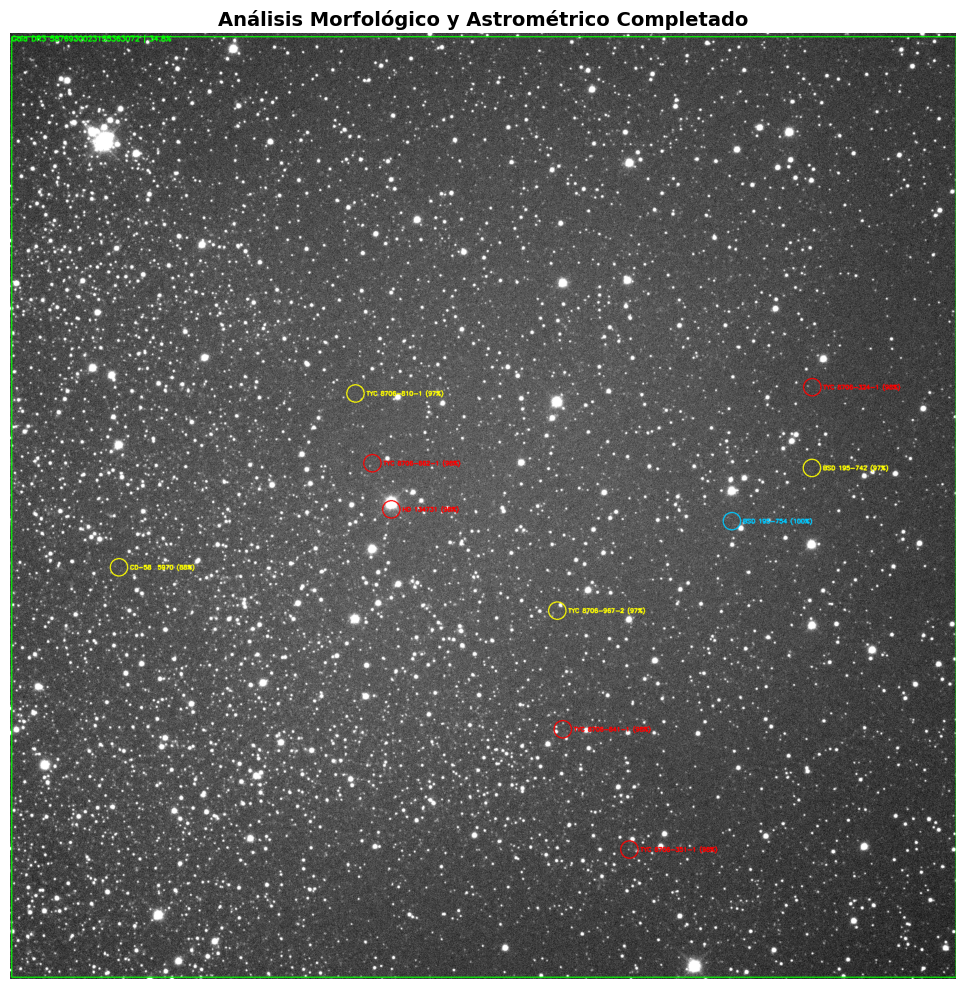


📊 REPORTE DE VALIDACIÓN (IA vs FÍSICA)


,ID,Nombre_Oficial,RA,Dec,Confianza_Detección,Morfologia_Ganadora,Distribución_IA (Top 10),Distribución_IA (Top 3)
0,OBJ_0,Gaia DR3 5876930023155363072,228.45785,-59.26405,98.79%,Disco de frente (Sin Espiral),1. Disco de frente (Sin Espiral) (34.8%) | 2. Espiral Apretada (33.2%) | 3. Disco de canto (Bulbo cuadrado) (20.2%),NaN
1,STAR_0,HD 134731,228.55271,-59.26308,100.00% (Gaia),Estrella Fría (Roja/Naranja),NaN,Seguridad IA: 97.6%
2,STAR_1,TYC 8706-351-1,228.31146,-59.08351,100.00% (Gaia),Estrella Fría (Roja/Naranja),NaN,Seguridad IA: 97.6%
3,STAR_2,TYC 8706-967-2,228.38331,-59.20925,100.00% (Gaia),Estrella Templada (Amarilla),NaN,Seguridad IA: 97.5%
4,STAR_3,TYC 8706-662-1,228.57217,-59.28729,100.00% (Gaia),Estrella Fría (Roja/Naranja),NaN,Seguridad IA: 97.6%
5,STAR_4,TYC 8706-841-1,228.37850,-59.14687,100.00% (Gaia),Estrella Fría (Roja/Naranja),NaN,Seguridad IA: 97.6%
6,STAR_5,CD-58 5970,228.83286,-59.23321,100.00% (Gaia),Estrella Templada (Amarilla),NaN,Seguridad IA: 87.5%
7,STAR_6,BSD 195-742,228.12043,-59.28276,100.00% (Gaia),Estrella Templada (Amarilla),NaN,Seguridad IA: 97.5%
8,STAR_7,TYC 8706-324-1,228.11895,-59.32522,100.00% (Gaia),Estrella Fría (Roja/Naranja),NaN,Seguridad IA: 97.6%
9,STAR_8,TYC 8706-810-1,228.58914,-59.32403,100.00% (Gaia),Estrella Templada (Amarilla),NaN,Seguridad IA: 97.5%



💾 Catálogo guardado en 'Catalogo_Validado_Final.csv'


In [8]:
# ==============================================================================
# 7. EJECUCIÓN DEL PIPELINE V1
# ==============================================================================
print("🚀 INICIANDO PIPELINE ASTROFÍSICO MODELO V1...\n")

# PASO 1: Organizar archivos revueltos
organizador = OrganizadorFITS(CARPETA_DESORDENADA)
organizador.organizar()

# PASO 2: Construir Archivos Maestros de Calibración
print("\n🛠️ CONSTRUYENDO MASTERS DE CALIBRACIÓN...")
reductor = MotorReduccion(dispositivo="GPU")

reductor.crear_master(CARPETA_BIAS, RUTA_MASTER_BIAS, tipo="Bias")
reductor.crear_master(CARPETA_DARK, RUTA_MASTER_DARK, tipo="Dark")
reductor.crear_master(CARPETA_FLAT, RUTA_MASTER_FLAT, tipo="Flat")

# PASO 3: Reducción Física e Inteligencia Artificial
# Buscar la primera imagen de ciencia disponible
archivos_ciencia = glob.glob(os.path.join(CARPETA_SCIENCE, "*.fit*"))

if archivos_ciencia:
    ruta_ciencia_actual = archivos_ciencia[0]
    nombre_base = os.path.basename(ruta_ciencia_actual).replace(".fits", "")
    ruta_salida_fits = f"procesado_{nombre_base}.fits"
    ruta_img_limpia_png = reductor.calibrar_imagen(
            ruta_ciencia_actual, 
            RUTA_MASTER_BIAS, 
            RUTA_MASTER_DARK, 
            RUTA_MASTER_FLAT, 
            ruta_salida_fits
        )
    


    # PASO 4: Astrometría, Detección, Morfología y Validación
    print("\n🔍 INICIANDO BÚSQUEDA Y CLASIFICACIÓN...")
    explorador = ExploradorCeleste(RUTA_MODELO_YOLO, API_KEY_ASTROMETRY, RUTA_MODELO_CNN)

    header_wcs = explorador.resolver_cielo(ruta_salida_fits, ruta_ciencia_actual)

    if header_wcs:
        print("   ✅ Cielo resuelto matemáticamente. Iniciando cruce de datos...")
        df_resultados = explorador.escanear_y_validar(ruta_img_limpia_png, header_wcs)
        
        print("\n==================================================")
        print("📊 REPORTE DE VALIDACIÓN (IA vs FÍSICA)")
        print("==================================================")
        display(df_resultados.head(10)) 
        
        df_resultados.to_csv("Catalogo_Validado_Final.csv", index=False)
        print("\n💾 Catálogo guardado en 'Catalogo_Validado_Final.csv'")
    else:
        print("\n❌ Falló la resolución astrométrica.")
else:
    print("\n❌ No se encontró ninguna imagen de ciencia en la carpeta Science.")